<a href="https://colab.research.google.com/github/MariaBatoorina/electric-vehicles-analysis/blob/main/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis

#Імпорти, налаштування та загрузка

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('visualizations', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

file_path = 'Electric_Vehicle_Data_CLEANED.csv'
df = pd.read_csv(file_path)

print(f"\nРозмір датасету:")
print(f"Рядків: {len(df):,}")
print(f"Колонок: {len(df.columns)}")


Розмір датасету:
Рядків: 250,658
Колонок: 20


#Model Year Distribution

In [5]:

mean_year = df['Model Year'].mean()
median_year = df['Model Year'].median()
mode_year = df['Model Year'].mode()[0]
min_year = df['Model Year'].min()
max_year = df['Model Year'].max()
count_2023 = df[df['Model Year'] == 2023].shape[0]

#print(f"Середнє: {mean_year:.1f}")
#print(f"Медіана: {median_year:.0f}")
#print(f"Мода: {mode_year:.0f}")
#print(f"Мінімум: {min_year:.0f}")
#print(f"Максимум: {max_year:.0f}")
#print(f"Авто 2023 року: {count_2023:,}")

q1 = df['Model Year'].quantile(0.25)
q3 = df['Model Year'].quantile(0.75)
iqr = q3 - q1

#print(f"Q1 (25%): {q1:.0f}")
#print(f"Q3 (75%): {q3:.0f}")
#print(f"IQR: {iqr:.0f}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['Model Year'] < lower_bound) | (df['Model Year'] > upper_bound)]

#print(f"\nВикиди:")
#print(f"Нижня межа: {lower_bound:.0f}")
#print(f"Верхня межа: {upper_bound:.0f}")
#print(f"Кількість викидів: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Q1 (25%): 2020
Q3 (75%): 2024
IQR: 4


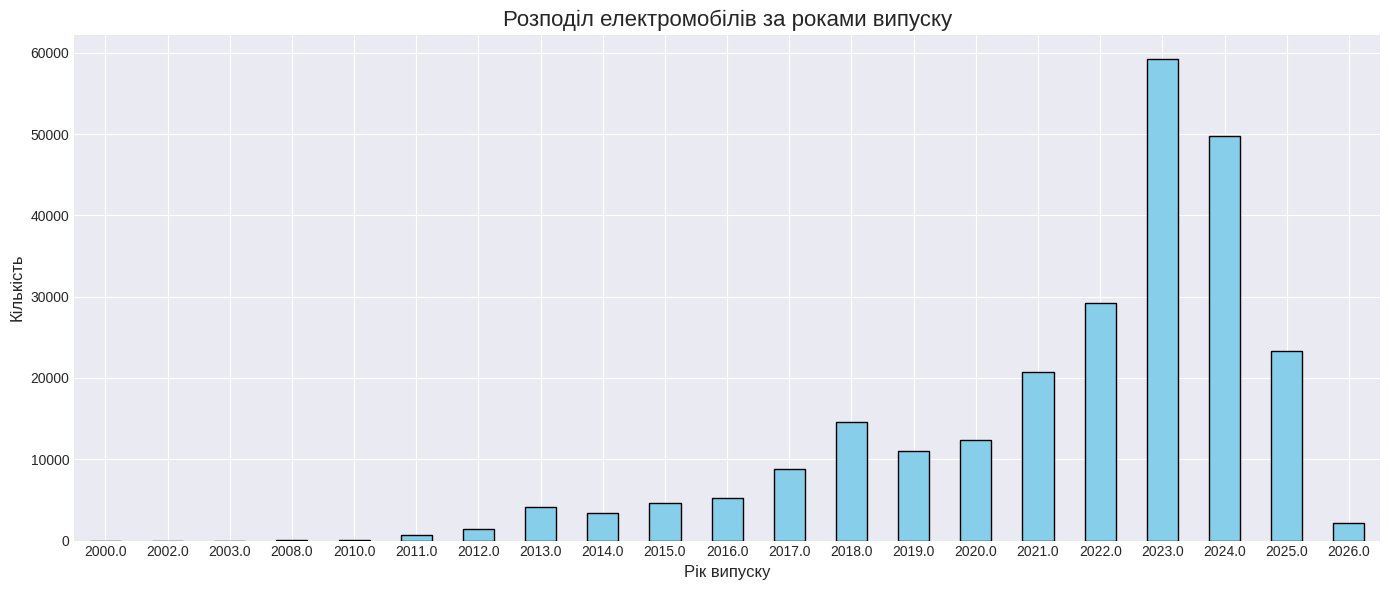

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
year_counts = df['Model Year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Розподіл електромобілів за роками випуску', fontsize=16)
ax.set_xlabel('Рік випуску', fontsize=12)
ax.set_ylabel('Кількість', fontsize=12)

ax.tick_params(axis='x', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('visualizations/1_model_year_distribution.png', dpi=300)
plt.show()

##Статистика:

* Середній рік: 2021.6
* Медіанний рік: 2023
* Найпопулярніший рік: 2023 (59,072 авто, ~23.6%)
* Діапазон років: 2000 - 2026
* 75% даних (Q1–Q3): 2020 – 2024

75% авто випущено в 2020–2024 роках - це підтверджує, що ринок електромобілів активно розвивається останніми роками.
25% даних припадає на період до 2020 року.

Найпопулярніший рік - 2023. На нього припадає 59072 реєстрації, що становить ~23.6% від усіх даних. Це означає, що майже кожне 4-те авто в датасеті - 2023 року випуску.

Медіана = 2023 — половина всіх авто (50%) випущена до 2023 року, половина - після.

Середній рік = 2021.6 - він менший за медіану (2023), що свідчить про наявність старих авто (до 2014), які "тягнуть" середнє значення вниз.

##Викиди та аномалії:

Кількість викидів: 6,277 (2.5%) - це авто з роками до 2014 року (нижня межа 2014).

Причина: Старі електромобілі (експериментальні моделі, ранні Tesla, Nissan Leaf тощо). Вони становлять незначну частину даних і не впливають на загальний тренд.

Роки > 2030: відсутні (максимальний рік у даних - 2026).

Висновок: Всі аномалії - це старі авто (до 2014), які можна виключити з аналізу або розглядати окремо.

##Рекомендації:

Для подальшого аналізу рекомендується виключити авто до 2014 року або розглядати їх окремо.

Роки до 2010 (поодинокі випадки) можна взагалі не враховувати в загальному аналізі.

Основний фокус аналізу — на період 2020–2024 років, де зосереджено 75% всіх даних.

#Top Makes

In [9]:
top_makes = df['Make'].value_counts().head(10)
total = len(df)

for i, (make, count) in enumerate(top_makes.items(), 1):
    pct = count / total * 100
    cum_pct = top_makes[:i].sum() / total * 100
    #print(f"{i:2}. {make:<20} {count:>8,} ({pct:>5.2f}%)")

#print(f"Всього виробників: {df['Make'].nunique()}")
#print(f"Топ-1: {top_makes.index[0]} ({top_makes.iloc[0]:,} авто, {top_makes.iloc[0]/total*100:.2f}%)")
#print(f"Топ-3: {top_makes.iloc[:3].sum():,} авто ({top_makes.iloc[:3].sum()/total*100:.2f}%)")
#print(f"Топ-5: {top_makes.iloc[:5].sum():,} авто ({top_makes.iloc[:5].sum()/total*100:.2f}%)")

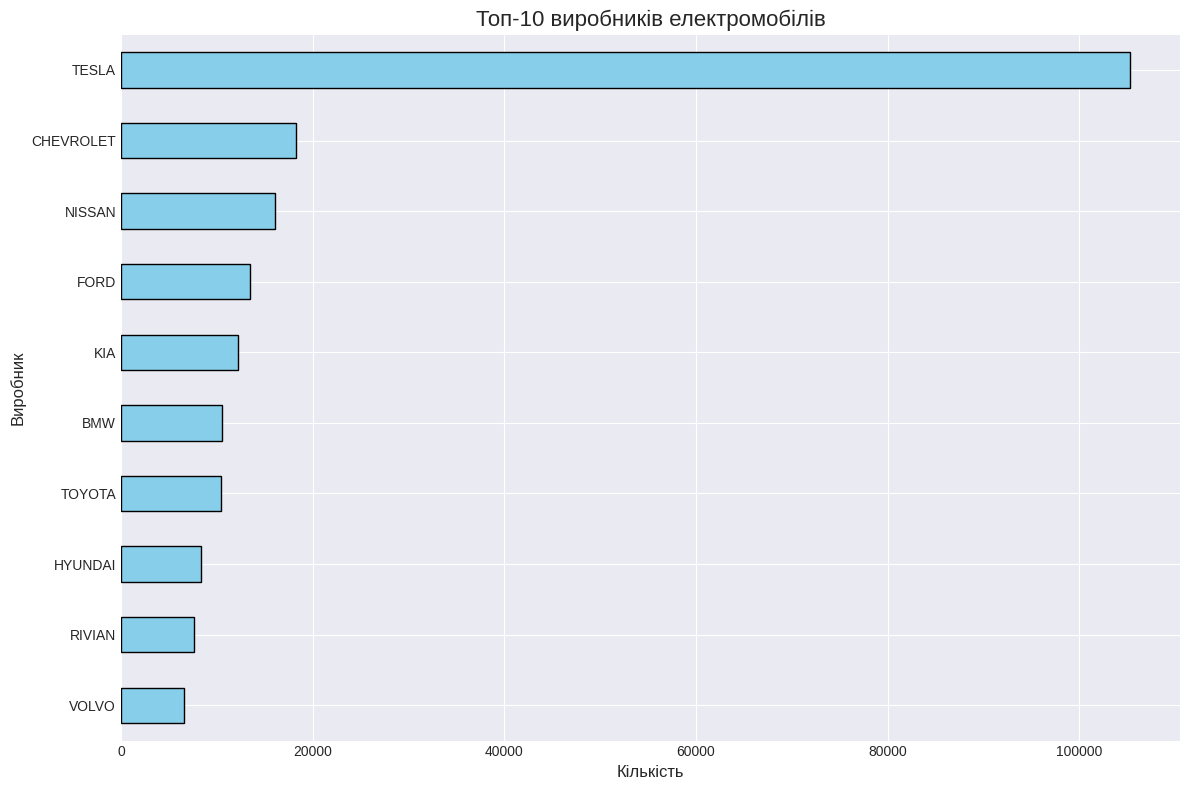

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))
top_makes = df['Make'].value_counts().head(10)
top_makes.sort_values().plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Топ-10 виробників електромобілів', fontsize=16)
ax.set_xlabel('Кількість', fontsize=12)
ax.set_ylabel('Виробник', fontsize=12)
plt.tight_layout()
plt.savefig('visualizations/2_top_makes.png', dpi=300)
plt.show()

##Статистика:

* Всього виробників: 46
* Лідер: Tesla (104,870 авто, 42.00%)
* Топ-3: 55.69% ринку
* Топ-5: 65.92% ринку
* Топ-10: 83.28% ринку

Tesla - лідер - 104,870 авто (42.00%) від усіх даних. Це більше, ніж у всіх інших виробників разом узятих. Кожне друге авто в датасеті - Tesla.

Топ-3 виробники (Tesla, Chevrolet, Nissan) займають 55.69% ринку - більше половини всіх електромобілів.

Топ-5 виробників (Tesla, Chevrolet, Nissan, Ford, KIA) займають 65.92% ринку - майже дві третини всіх авто.

Топ-10 виробників займають 83.28% ринку. Це означає, що лише 10 брендів контролюють більшість ринку, а решта 36 виробників ділять між собою лише 16.72%.

##Аномалії та особливості:

Домінування Tesla - 42% ринку є - високим показником. Це свідчить про те, що Tesla є головним драйвером ринку електромобілів.

Розрив між Tesla та іншими - другий виробник (Chevrolet) має лише 7.26%, що в 6 разів менше, ніж Tesla.

Фрагментований ринок - 36 виробників ділять між собою лише 16.72% ринку.

##Рекомендації:

Для подальшого аналізу можна виділити Tesla окремо, а інших виробників групувати.

Малі бренди (з часткою < 1%) можна об'єднати в категорію "Інші".

#EV Types

In [13]:
ev_types = df['Electric Vehicle Type'].value_counts()
total = len(df)

for ev_type, count in ev_types.items():
    pct = count / total * 100
    #print(f"{ev_type}: {count:,} ({pct:.2f}%)")

if len(ev_types) >= 2:
    bev = ev_types.iloc[0]
    phev = ev_types.iloc[1]
    ratio = bev / phev
    #print(f"\nСпіввідношення BEV : PHEV = {ratio:.1f} : 1")

    diff = bev - phev
    #print(f"BEV більше на {diff:,} авто")

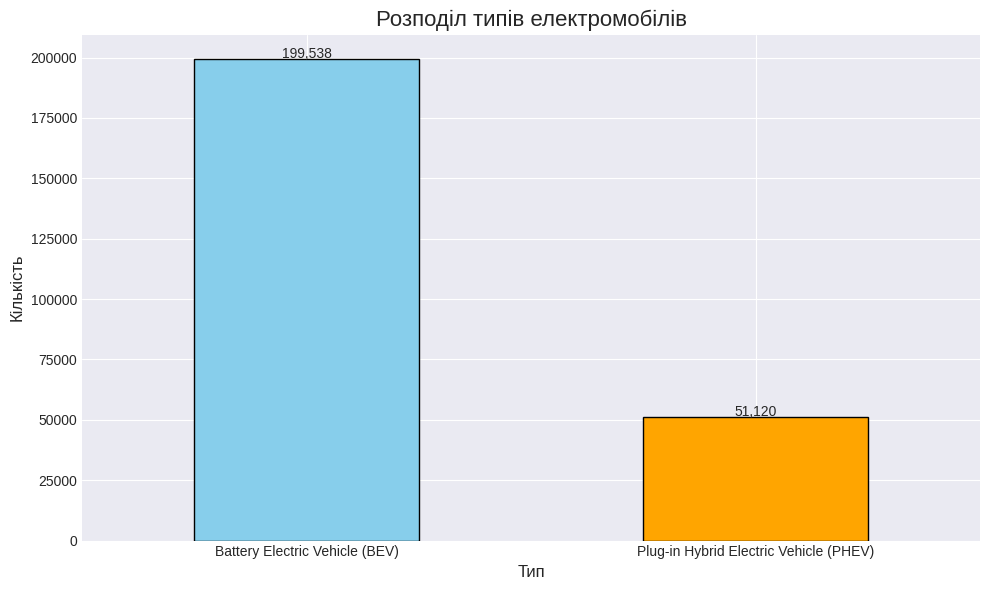

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ev_types = df['Electric Vehicle Type'].value_counts()
ev_types.plot(kind='bar', ax=ax, color=['skyblue', 'orange'], edgecolor='black')
ax.set_title('Розподіл типів електромобілів', fontsize=16)
ax.set_xlabel('Тип', fontsize=12)
ax.set_ylabel('Кількість', fontsize=12)

ax.tick_params(axis='x', rotation=0, labelsize=10)

for i, v in enumerate(ev_types.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/3_ev_types.png', dpi=300)
plt.show()

##Статистика:
* BEV: 198,782 авто (79.62%)
* PHEV: 50,892 авто (20.38%)
* Співвідношення: 3.9 : 1 (BEV : PHEV)
* Різниця: 147,890 авто

BEV (Battery Electric Vehicle) домінує - 198,782 авто (79.62%) від усіх даних. Це означає, що майже 4 з 5 електромобілів є повністю електричними.

PHEV (Plug-in Hybrid Electric Vehicle) - становить значно меншу частку - 50,892 авто (20.38%) - лише кожне 5-те авто є гібридом.

Співвідношення BEV : PHEV = 3.9 : 1 - на кожен PHEV припадає майже 4 повністю електричних авто. Це свідчить про те, що споживачі віддають перевагу саме BEV.

Різниця між BEV та PHEV становить 147,890 авто - це величезний розрив, який підтверджує, що ринок електромобілів орієнтується на повністю електричні моделі.

##Висновок:

Більшість споживачів обирають повністю електричні автомобілі (BEV), що свідчить про:
*   довіру до технології електромобілів;
*   розвиток зарядної інфраструктури;
*   збільшення запасу ходу сучасних BEV;

#Electric Range Distribution

In [15]:
if 'Electric Range Clean' in df.columns:
    range_data = df['Electric Range Clean'].dropna()
else:
    range_data = df[df['Electric Range'] > 0]['Electric Range']

total = len(range_data)

#print(f"Кількість: {total:,}")
#print(f"Мінімум: {range_data.min():.0f} миль")
#print(f"Максимум: {range_data.max():.0f} миль")
#print(f"Середнє: {range_data.mean():.1f} миль")
#print(f"Медіана: {range_data.median():.0f} миль")
#print(f"Стандартне відхилення: {range_data.std():.1f} миль")

q1 = range_data.quantile(0.25)
q3 = range_data.quantile(0.75)
iqr = q3 - q1

#print(f"Q1 (25%): {q1:.0f} миль")
#print(f"Q3 (75%): {q3:.0f} миль")
#print(f"IQR: {iqr:.0f} миль")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = range_data[(range_data < lower_bound) | (range_data > upper_bound)]

#print(f"\nВикиди:")
#print(f"Нижня межа: {lower_bound:.0f} миль")
#print(f"Верхня межа: {upper_bound:.0f} миль")
#print(f"Кількість викидів: {len(outliers)} ({len(outliers)/total*100:.2f}%)")

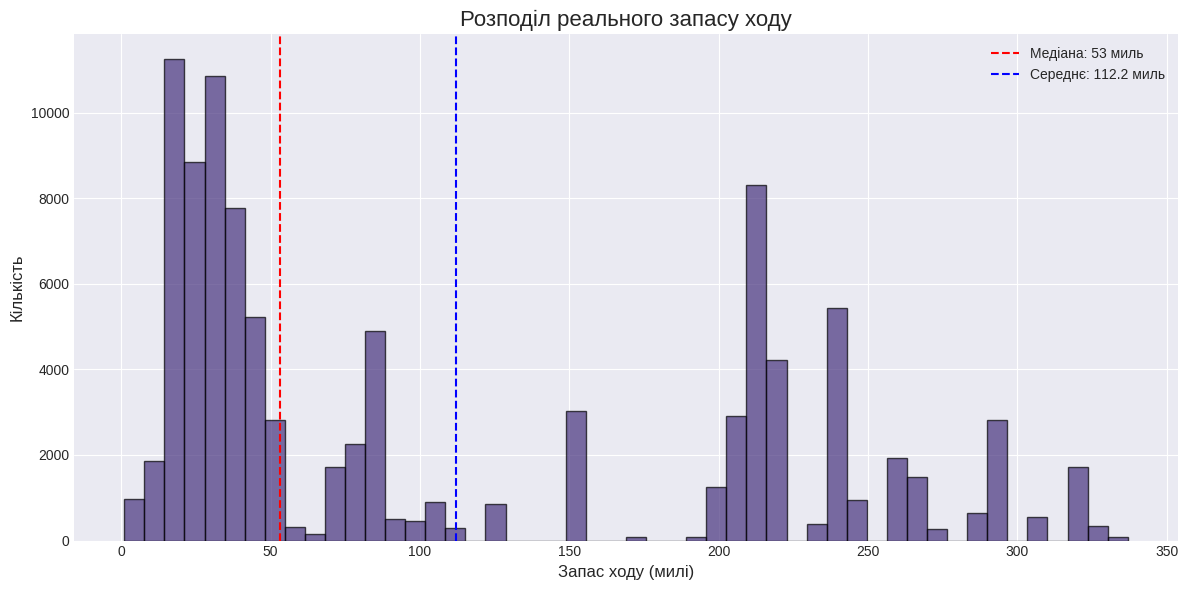

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

if 'Electric Range Clean' in df.columns:
   range_data = df['Electric Range Clean'].dropna()
else:
   range_data = df[df['Electric Range'] > 0]['Electric Range']


range_data.hist(bins=50, edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Розподіл реального запасу ходу', fontsize=16)
ax.set_xlabel('Запас ходу (милі)', fontsize=12)
ax.set_ylabel('Кількість', fontsize=12)
ax.axvline(range_data.median(), color='red', linestyle='--',
          label=f'Медіана: {range_data.median():.0f} миль')
ax.axvline(range_data.mean(), color='blue', linestyle='--',
          label=f'Середнє: {range_data.mean():.1f} миль')
ax.legend()
plt.tight_layout()
plt.savefig('visualizations/4_electric_range_distribution.png', dpi=300)
plt.show()

##Статистика:

Кількість: 98,070 авто
Мінімум: 1 миля
Максимум: 337 миль
Середнє: 112.2 миль
Медіана: 53 милі
Q1–Q3: 30 - 215 миль
Стандартне відхилення: 98.2 миль

##Ключові висновки:

Типовий запас ходу - 53 милі (медіана). Це означає, що половина електромобілів мають запас ходу менше 53 миль, половина - більше.

Середній запас ходу - 112 миль - значно вищий за медіану. Це свідчить про те, що є невелика кількість авто з дуже великим запасом ходу (до 337 миль), які "тягнуть" середнє вгору.

Розподіл має довгий "хвіст" вправо - більшість авто (75%) мають запас ходу до 215 миль, але є авто з запасом до 337 миль.

Викидів немає - всі значення в межах норми (верхня межа 492 миль, а максимум 337).

Більшість електромобілів мають запас ходу до 53 миль, що характерно для старих моделей або PHEV. Однак на ринку з'являються авто з запасом понад 200 миль, що свідчить про технологічний прогрес.

#Range by Year

In [40]:
df_range = df[df['Electric Range'] > 0].copy()

count_by_year_type = df_range.groupby(
    ['Model Year', 'Electric Vehicle Type']
).size().reset_index(name='Count')

pivot_counts = count_by_year_type.pivot(
    index='Model Year',
    columns='Electric Vehicle Type',
    values='Count'
).fillna(0).astype(int)

#print("\nКількість авто по роках і типах:")
#print(pivot_counts)

for year in pivot_counts.index:
    bev_count = pivot_counts.loc[year, 'Battery Electric Vehicle (BEV)'] if 'Battery Electric Vehicle (BEV)' in pivot_counts.columns else 0
    phev_count = pivot_counts.loc[year, 'Plug-in Hybrid Electric Vehicle (PHEV)'] if 'Plug-in Hybrid Electric Vehicle (PHEV)' in pivot_counts.columns else 0

    #if bev_count < 50:
        #print(f"{year:.0f}: BEV - {bev_count} авто (мало даних)")
    #elif phev_count < 50:
        #print(f"{year:.0f}: PHEV - {phev_count} авто (мало даних)")
    #else:
        #print(f"{year:.0f}: BEV - {bev_count}, PHEV - {phev_count}")


In [41]:
bev_data = df_range[df_range['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']

bev_by_year = bev_data.groupby('Model Year')['Electric Range'].median()
bev_mean_by_year = bev_data.groupby('Model Year')['Electric Range'].mean()

#print("\nМедіанний запас ходу BEV по роках:")
#print(bev_by_year)

print(f"\nСтатистика BEV:")
print(f"Кількість записів: {len(bev_data):,}")
print(f"Мінімальний запас: {bev_data['Electric Range'].min():.0f} миль")
print(f"Максимальний запас: {bev_data['Electric Range'].max():.0f} миль")
print(f"Середнє: {bev_data['Electric Range'].mean():.1f} миль")
print(f"Медіана: {bev_data['Electric Range'].median():.0f} миль")

bev_corr = bev_data['Model Year'].corr(bev_data['Electric Range'])
print(f"\nКореляція BEV:")
print(f"Кореляція між роком та запасом ходу: {bev_corr:.2f}")

if bev_corr > 0.7:
    print("Сильний позитивний зв'язок — запас ходу стрімко зростає з роками")
else:
    print("Помірний позитивний зв'язок")


Статистика BEV:
Кількість записів: 47,383
Мінімальний запас: 29 миль
Максимальний запас: 337 миль
Середнє: 199.2 миль
Медіана: 215 миль

Кореляція BEV:
Кореляція між роком та запасом ходу: 0.71
Сильний позитивний зв'язок — запас ходу стрімко зростає з роками


## Ключові висновки:

1. Дані після 2020 року неповні - у датасеті майже відсутні BEV (повністю електричні авто) після 2020 року.

2. PHEV домінують у 2021-2024 роках - це пояснює падіння медіани запасу ходу (PHEV мають малий запас - 19-38 миль).

### Статистика:
| Показник | BEV | PHEV |
|----------|-----|------|
| **Тренд** | Зростає | Стабільний |
| **Діапазон** | 210 - 308 миль | 19 - 38 миль |
| **Кореляція** | Сильна позитивна | Слабка |


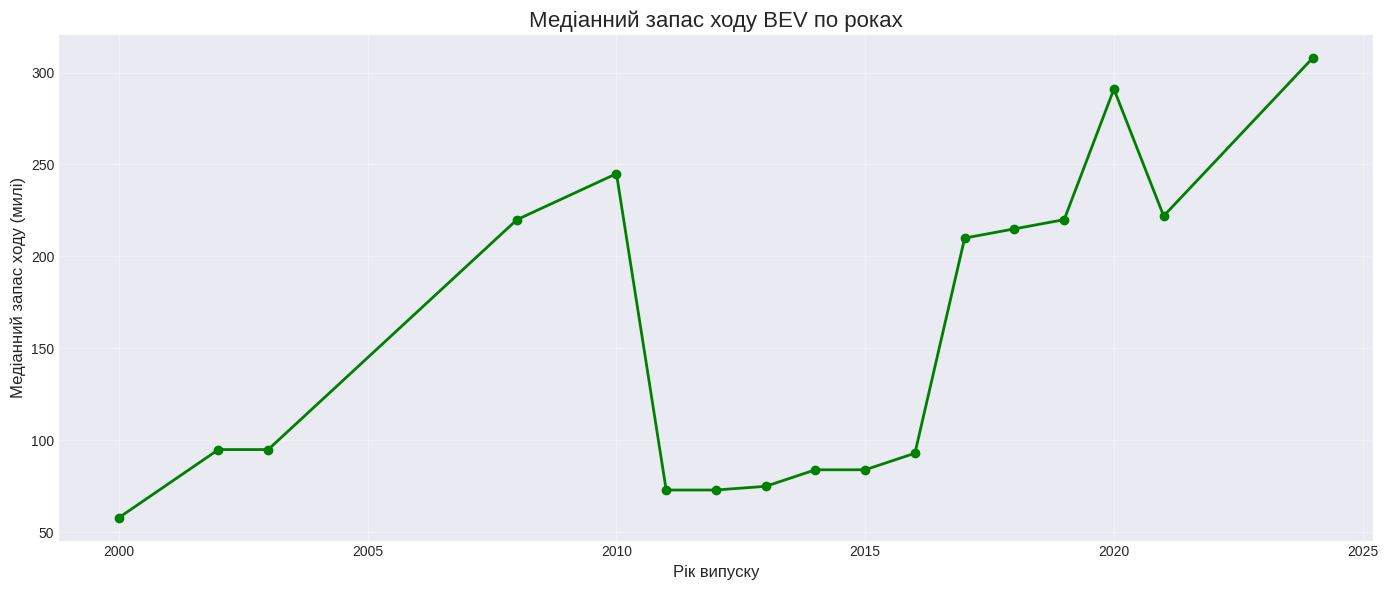

In [42]:
#BEV

bev_data = df_range[df_range['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']
bev_by_year = bev_data.groupby('Model Year')['Electric Range'].median()

fig, ax = plt.subplots(figsize=(14, 6))
bev_by_year.plot(kind='line', marker='o', ax=ax, color='green', linewidth=2)
ax.set_title('Медіанний запас ходу BEV по роках', fontsize=16)
ax.set_xlabel('Рік випуску', fontsize=12)
ax.set_ylabel('Медіанний запас ходу (милі)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/bev_range_by_year.png', dpi=300)
plt.show()

## Ключові висновки:

1. Запас ходу BEV стрімко зростає - з ~210 миль (2017) до ~308 миль (2024). Це підтверджує технологічний прогрес у галузі електромобілів.

2. Кореляція сильна позитивна - чим новіший автомобіль, тим більший запас ходу. Це свідчить про покращення батарей та ефективності двигунів.

3. Стрибок у 2020 році - різке зростання запасу ходу до 291 миль, що пов'язано з виходом нових моделей з великими батареями (Tesla Model Y, Mustang Mach-E).

4. Стабільне зростання після 2020 - запас ходу продовжує зростати, досягаючи 308 миль у 2024 році.

## Висновок:
Технології BEV стрімко розвиваються - за 7 років запас ходу зріс майже на 100 миль. Це робить електромобілі все більш привабливими для споживачів.

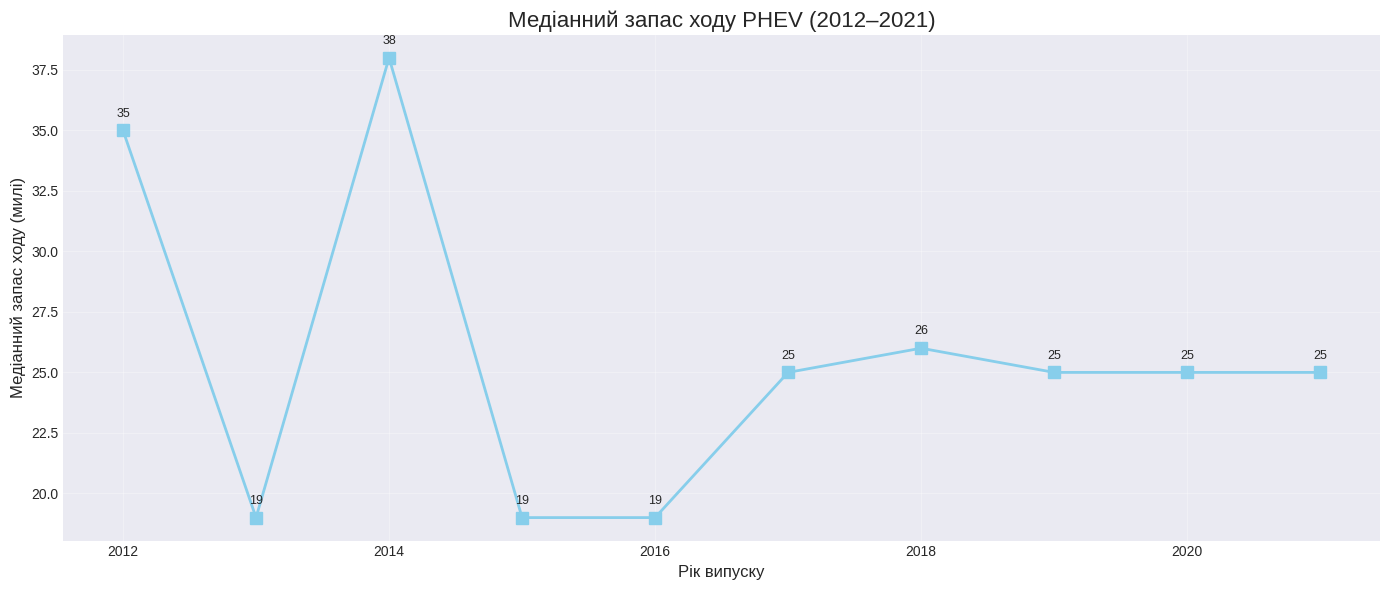

In [36]:
#PHEV (2012–2021)

phev_by_year = phev_data.groupby('Model Year')['Electric Range'].median()
fig, ax = plt.subplots(figsize=(14, 6))
phev_by_year.plot(kind='line', marker='s', ax=ax, color='skyblue', linewidth=2, markersize=8)
ax.set_title('Медіанний запас ходу PHEV (2012–2021)', fontsize=16)
ax.set_xlabel('Рік випуску', fontsize=12)
ax.set_ylabel('Медіанний запас ходу (милі)', fontsize=12)
ax.grid(True, alpha=0.3)

for year, value in phev_by_year.items():
    ax.annotate(f'{value:.0f}',
                xy=(year, value),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=9)

plt.tight_layout()
plt.savefig('visualizations/phev_range_by_year.png', dpi=300)
plt.show()

### Ключові висновки:

1. Запас ходу PHEV майже не змінюється - протягом 2012–2021 років медіана залишається в діапазоні 20-50 миль.

2. Кореляція слабка - рік випуску майже не впливає на запас ходу PHEV.

3. Причина: PHEV завжди мають невелику батарею (для 20-50 миль електричного ходу), оскільки вони розраховані на комбіноване використання з бензиновим двигуном.

4. Висновок: На відміну від BEV, технології PHEV не демонструють значного прогресу в запасі ходу.

#Top Cities Counties

In [44]:
top_cities = df['City'].value_counts().head(10)
top_counties = df['County'].value_counts().head(10)
total = len(df)

#for i, (city, count) in enumerate(top_cities.items(), 1):
#    pct = count / total * 100
#    print(f"{i:2}. {city:<25} {count:>8,} ({pct:>5.2f}%)")

#print(f"\nТоп 10 округів:")
#for i, (county, count) in enumerate(top_counties.items(), 1):
#    pct = count / total * 100
#    print(f"{i:2}. {county:<25} {count:>8,} ({pct:>5.2f}%)")

print(f"\nЗагальна статистика:")
print(f"Всього міст: {df['City'].nunique()}")
print(f"Всього округів: {df['County'].nunique()}")
print(f"Найпопулярніше місто: {top_cities.index[0]} ({top_cities.iloc[0]:,} авто, {top_cities.iloc[0]/total*100:.2f}%)")
print(f"Найпопулярніший округ: {top_counties.index[0]} ({top_counties.iloc[0]:,} авто, {top_counties.iloc[0]/total*100:.2f}%)")


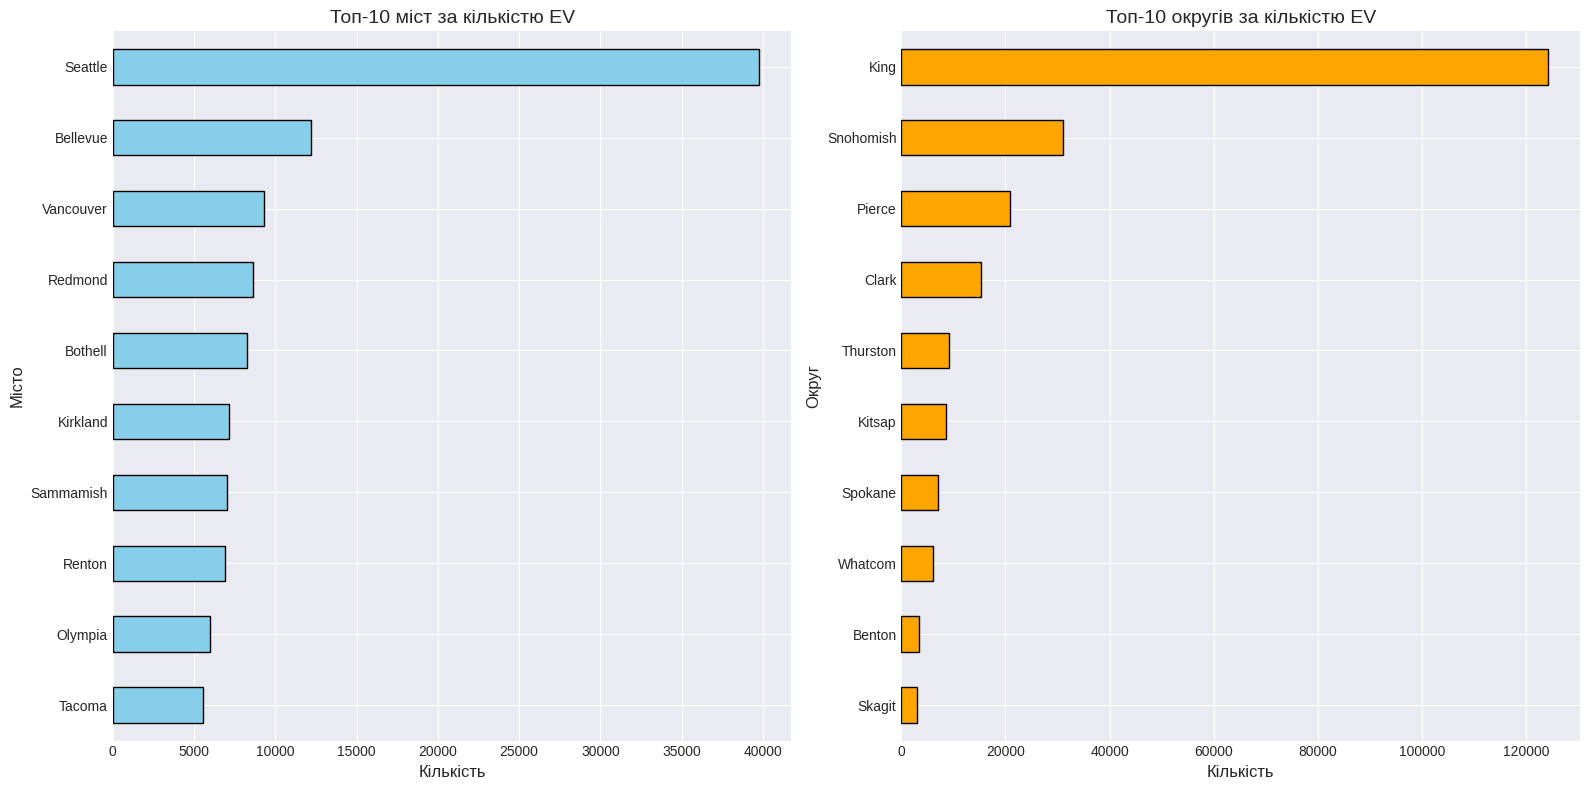

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_cities = df['City'].value_counts().head(10)
top_cities.sort_values().plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Топ-10 міст за кількістю EV', fontsize=14)
axes[0].set_xlabel('Кількість', fontsize=12)
axes[0].set_ylabel('Місто', fontsize=12)

top_counties = df['County'].value_counts().head(10)
top_counties.sort_values().plot(kind='barh', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Топ-10 округів за кількістю EV', fontsize=14)
axes[1].set_xlabel('Кількість', fontsize=12)
axes[1].set_ylabel('Округ', fontsize=12)

plt.tight_layout()
plt.savefig('visualizations/6_top_cities_counties.png', dpi=300)
plt.show()

###Статистика:

* Всього міст: 813
* Всього округів: 224
* Найпопулярніше місто: Seattle (39,739 авто, 15.92%)
* Найпопулярніший округ: King (124,118 авто, 49.71%)
* Топ-3 округи: 70.35% ринку
* Топ-5 міст: 31.30% ринку

###Ключові висновки:

Seattle - лідер - 39,739 авто (15.92%) від усіх даних. Це більше, ніж у наступних 3 міст разом узятих.

King County домінує - 124,118 авто (49.71%) - майже половина всіх електромобілів знаходиться в цьому окрузі. Це пояснюється тим, що King County включає Сіетл і є економічним та технологічним центром штату.

Топ-3 округи (King, Snohomish, Pierce) займають 70.35% всіх реєстрацій. Це означає, що більшість електромобілів зосереджена всього в 3 округах.

Топ-5 міст (Seattle, Bellevue, Vancouver, Redmond, Bothell) займають 31.30% ринку.

Розподіл нерівномірний - 813 міст і 224 округи, але більшість авто зосереджена у великих містах.

###Аномалії та особливості:

King County — 49.71% всіх EV — це висока концентрація. Це пояснюється тим, що тут знаходиться Сіетл - великий технологічний центр із розвиненою інфраструктурою.

Snohomish та Pierce - наступні за концентрацією (12.40% та 8.24%) - разом із King покривають понад 70% ринку.

Мала кількість EV у сільських округах - свідчить про необхідність розвитку зарядної інфраструктури за межами великих міст.